In [1]:
import pandas as pd

df = pd.read_csv("../data/exploration.csv")

We use codebert-base to vectorize the code which gives relatively few dimensions(768) and leverages code patterns learned from a larger corpus than ours

In [2]:
import sys
sys.path.append("..")

from python_editor.data_processing import vectorize_code

embeddings = vectorize_code(df["text"])
embeddings.shape

100%|██████████| 3714/3714 [1:33:33<00:00,  1.51s/it]  


(3714, 768)

UMAP helps us visualize the 768 dimensions by reducing them to only 2

In [3]:
import umap

umap_embedder = umap.UMAP()
umap_emb = umap_embedder.fit_transform(embeddings)

We can see three main chunks where the middle small one has mainly low score

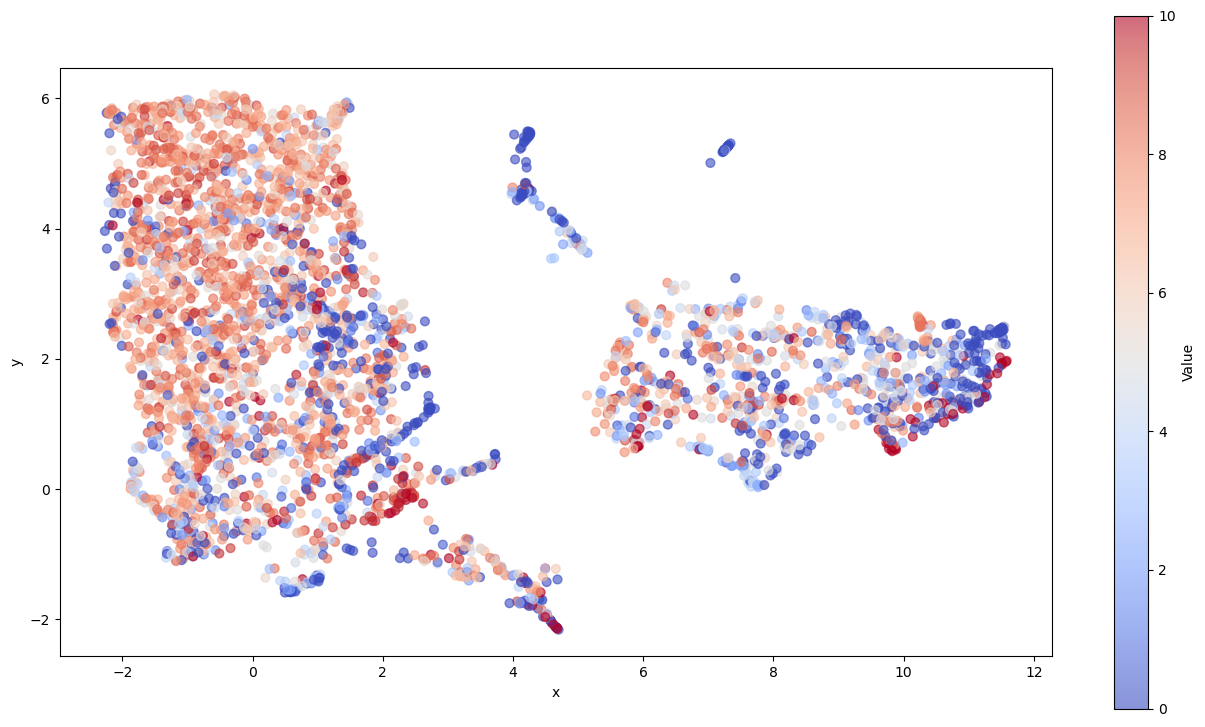

In [4]:
from python_editor.data_visualization import plot_embeddings

plot_embeddings(umap_emb, df["pylint_score"])

We add embeddings to our df and save it for easy loading later

In [7]:
df["embedding"] = list(embeddings)
df.to_pickle("../data/embeddings.pkl")